<div style="text-align: center">

# WQD7003 - Data Analytics

## Predictive Analytics for Mental Health Risk Assessment:
## A CRISP-DM Approach

<br>

**Group 3**

**Group Members:**

Faiz Yah Bin Abdul Hanan Yah (24087980)

Chua Wei Shyong (24235116)

Ma LingLong (25062663)

Moo Nee Choong (25069338)

<br>

**Date:** January 2026

</div>

---

# Table of Contents
1. Introduction and Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment
7. Conclusion
---

# 1. Introduction and Business Understanding

## 1.1 Project Methodology
This project follows the CRISP-DM framework (Cross-Industry Standard Process for Data Mining), a systematic and iterative approach for data science projects comprising six main phases:

1. Business Understanding: Define project objectives and requirements
2. Data Understanding: Explore and analyze available data
3. Data Preparation: Clean and transform data for modeling
4. Modeling: Develop and train machine learning algorithms
5. Evaluation: Assess model performance and validity
6. Deployment: Plan implementation and monitoring strategies

This structure ensures a rigorous and reproducible approach suited for public health applications.

## 1.2 Project Background

Mental health has emerged as one of the most critical public health challenges of the 21st century. In 2021, approximately 1.1 billion people globally were living with mental disorder, anxiety and depressive disorder [1].
- Despite growing advances in treatment research, early detection of mental health disorders remains a fundamental barrier to effective intervention.

## 1.3 Problem Statement

Manual screening processes has such limitations [2],[3]:
- Rely on self-reporting and clinical interviews
- Occur only after symptoms have emerged
- Struggle to account for the complex interplay of various factors

There is an urgent need for scalable and data-driven approaches that can identify at-risk individuals earlier in the disease progression.

## 1.3 Project Objectives

Aligned with **Sustainable Development Goal 3 (Good Health and Well-being)**, this project leverages machine learning techniques to develop a predictive solution for early mental health risk identification. Three primary objectives are defined as follows:

**1 Mental Health Risk Prediction (Binary Classification Task):**
- Develop classification models that accurately predict whether an individual has a history of mental illness based on demographic, lifestyle, and health-related factors

**2 Feature Importance and Risk Factor Analysis:**
- Identify and quantify the key demographic, lifestyle, and health-related factors most strongly associated with mental illness history

**3 Model Performance Optimization:**
- Compare multiple machine learning algorithms to determine the optimal approach for mental health risk prediction

## 1.4 Setup and Dependencies Imports

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Statistical Analysis
from scipy import stats
from scipy.stats import chi2_contingency

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Gradient Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Model Interpretation
import shap

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

---

# 2. Data Understanding

## 2.1 Dataset Introduction

**Dataset Source:** Kaggle - Mental Health Depression Dataset

**Dataset Characteristics:**
- **Size:** 413,768 observations
- **Features:** 15 predictive variables + 1 target variable
- **Feature Types:** 3 numerical, 12 categorical
- **Target Variable:** History of Mental Illness (Binary: Yes/No)
- **Class Distribution:** ~70% No, ~30% Yes (imbalanced)

**Variables:**

*Numerical:*
- Age (years)
- Income (annual)
- Number of Children

*Categorical:*
- Employment Status, Education Level, Marital Status
- Physical Activity Level, Dietary Habits, Sleep Patterns
- Smoking Status, Alcohol Consumption
- History of Substance Abuse, Family History of Depression
- Chronic Medical Conditions

In [ ]:
# Load Dataset
pathway = "..."
df = pd.read_csv(pathway)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (413768, 16)

First 5 rows:


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


## 2.2 Exploratory Data Analysis (EDA)

### 2.2.1 Initial Data Exploration

In [ ]:
# Data Overview
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413768 entries, 0 to 413767
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   Name                          413768 non-null  object  
 1   Age                           413768 non-null  int64   
 2   Marital Status                413768 non-null  category
 3   Education Level               413768 non-null  category
 4   Number of Children            413768 non-null  int64   
 5   Smoking Status                413768 non-null  category
 6   Physical Activity Level       413768 non-null  category
 7   Employment Status             413768 non-null  category
 8   Income                        413768 non-null  float64 
 9   Alcohol Consumption           413768 non-null  category
 10  Dietary Habits                413768 non-null  category
 11  Sleep Patterns                413768 non-null  category
 12  History of Menta

In [ ]:
#Convert Categorial Variables in to Categorial Data Type
df['Marital Status'] = df['Marital Status'].astype('category')
df['Education Level'] = pd.Categorical(df['Education Level'], categories=['High School', 'Associate Degree', 'Bachelor\'s Degree', 'Master\'s Degree', 'PhD'], ordered=True) #ordered category
df['Smoking Status'] = df['Smoking Status'].astype('category')
df['Physical Activity Level'] = df['Physical Activity Level'].astype('category')
df['Employment Status'] = df['Employment Status'].astype('category')
df['Alcohol Consumption'] = pd.Categorical(df['Alcohol Consumption'], categories=['Low', 'Moderate', 'High'], ordered=True) #ordered category
df['Dietary Habits'] = pd.Categorical(df['Dietary Habits'], categories=['Unhealthy', 'Moderate', 'Healthy'], ordered=True) #ordered category
df['Sleep Patterns'] = pd.Categorical(df['Sleep Patterns'], categories=['Poor', 'Fair', 'Good'], ordered=True) #ordered category
df['History of Mental Illness'] = df['History of Mental Illness'].astype('category')
df['History of Substance Abuse'] = df['History of Substance Abuse'].astype('category')
df['Family History of Depression'] = df['Family History of Depression'].astype('category')
df['Chronic Medical Conditions'] = df['Chronic Medical Conditions'].astype('category')

In [ ]:
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Name                            0
Age                             0
Marital Status                  0
Education Level                 0
Number of Children              0
Smoking Status                  0
Physical Activity Level         0
Employment Status               0
Income                          0
Alcohol Consumption             0
Dietary Habits                  0
Sleep Patterns                  0
History of Mental Illness       0
History of Substance Abuse      0
Family History of Depression    0
Chronic Medical Conditions      0
dtype: int64


In [ ]:
# Duplicated Values
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [ ]:
print("\nStatistical Summary:")
df.describe().round(2)


Statistical Summary:


,Age,Number of Children,Income
count,413768.00,413768.00,413768.00
mean,49.00,1.30,50661.71
std,18.16,1.24,40624.10
min,18.00,0.00,0.41
25%,33.00,0.00,21001.03
50%,49.00,1.00,37520.13
75%,65.00,2.00,76616.30
max,80.00,4.00,209995.22


**Key Insights**:
- No missing values detected
- No duplicate records
- Income has outliers

Target Variable Distribution:
History of Mental Illness
No     287943
Yes    125825
Name: count, dtype: int64

Class Proportions:
History of Mental Illness
No     0.695904
Yes    0.304096
Name: proportion, dtype: float64


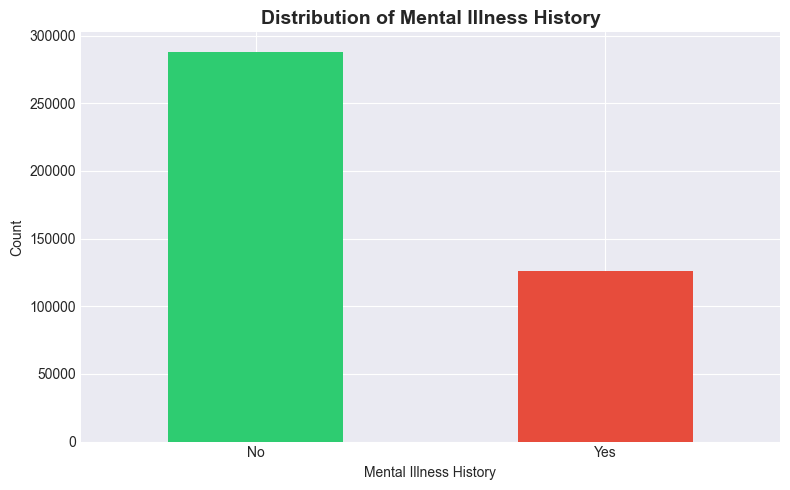

In [ ]:
# Target Variable Distribution
print("Target Variable Distribution:")
print(df['History of Mental Illness'].value_counts())
print("\nClass Proportions:")
print(df['History of Mental Illness'].value_counts(normalize=True))

# Visualization
plt.figure(figsize=(8, 5))
df['History of Mental Illness'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Mental Illness History', fontsize=14, fontweight='bold')
plt.xlabel('Mental Illness History')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Key Insights**: It is an imbalanced data, siginifying that an data imbalanced strategy is required to achieve better model performance.

### 2.2.2 Univariate Analysis

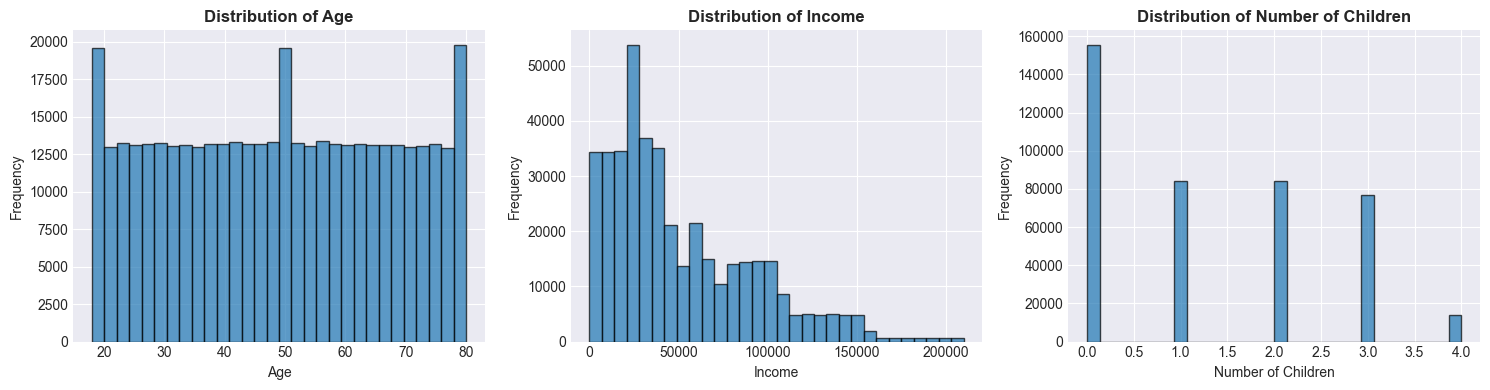

In [ ]:
# Numerical Variables Distribution
numerical_cols = ['Age', 'Income', 'Number of Children']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Key Insights**:
- Age is fairly uniformly distributed
- Income has a right-tail distribution with majority of income at the lower value
- Majority of sample do not have any childeren, and the number decreases as number of childeren increases

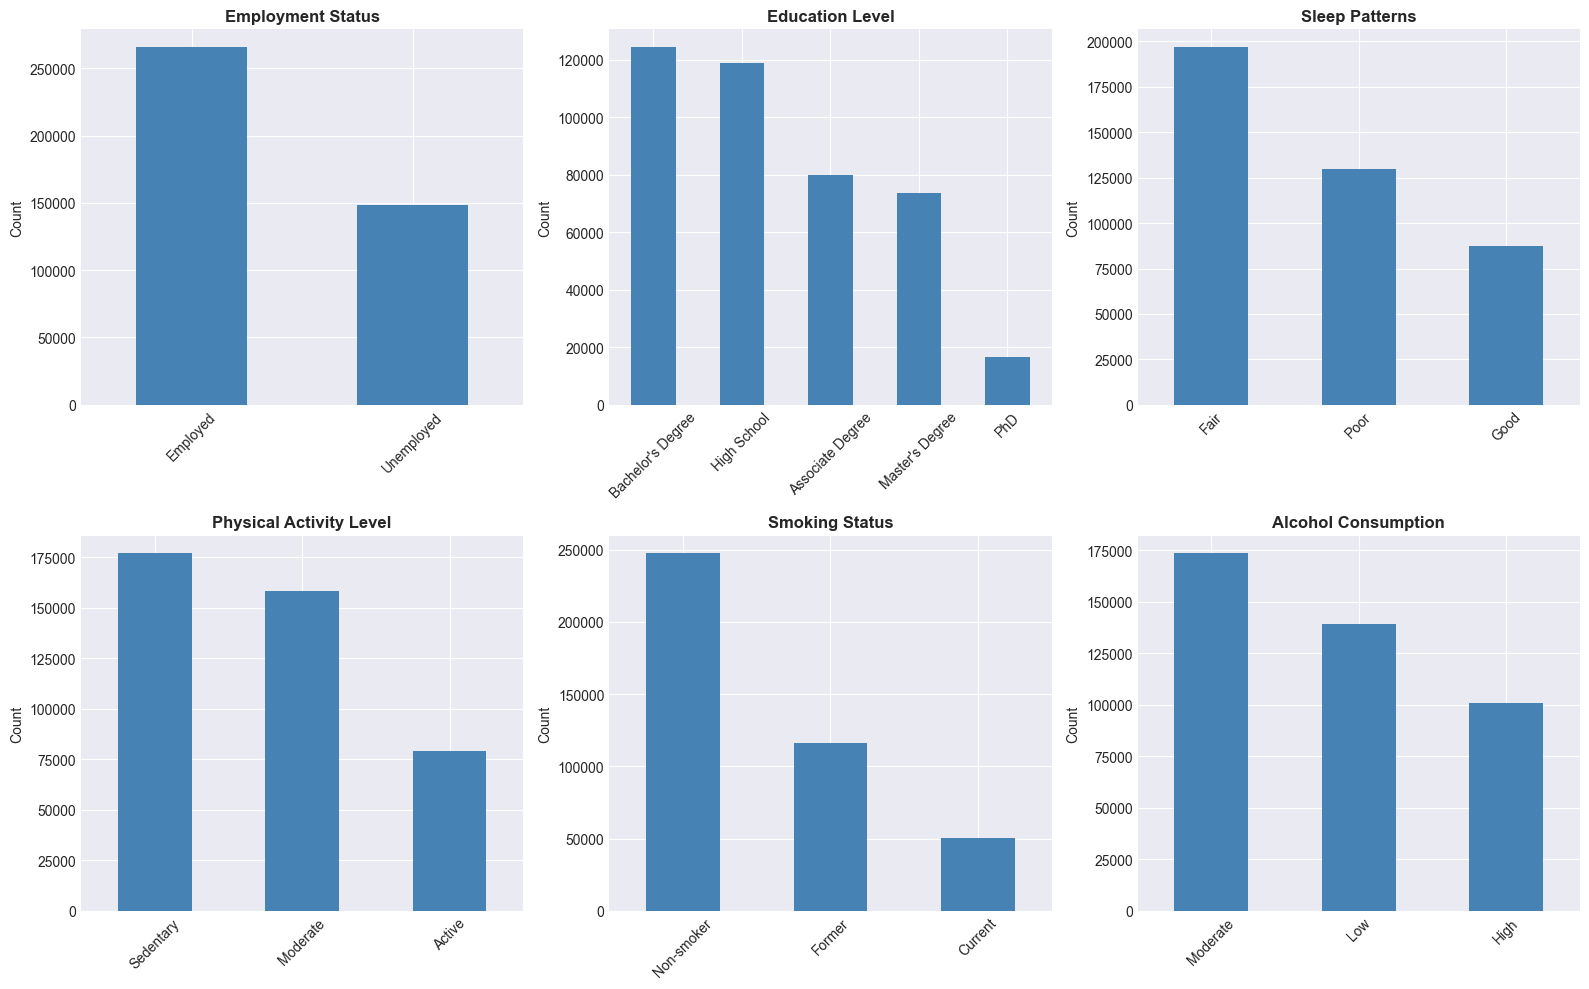

In [ ]:
# Categorical Variables Distribution (Key Variables)
categorical_cols = ['Employment Status', 'Education Level', 'Sleep Patterns',
                   'Physical Activity Level', 'Smoking Status', 'Alcohol Consumption']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Key Insights**:
- All the categorical columns do not have a uniform distribution

### 2.2.3 Bivariate Analysis

**Key Relationships with Target Variable**

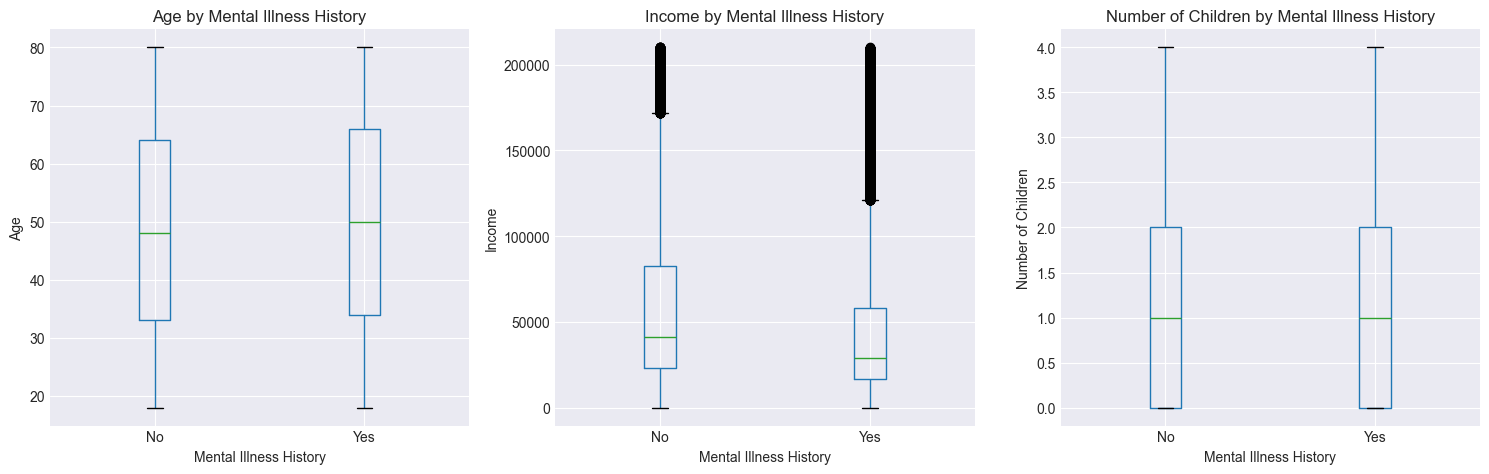


T-Test Results (Mental Illness: Yes vs No):
Age: t-statistic = 15.8818, p-value = 8.8096e-57
Income: t-statistic = -88.8344, p-value = 0.0000e+00
Number of Children: t-statistic = 1.7453, p-value = 8.0940e-02


In [ ]:
# Numerical vs Target Variable
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, by='History of Mental Illness', ax=axes[i])
    axes[i].set_title(f'{col} by Mental Illness History')
    axes[i].set_xlabel('Mental Illness History')
    axes[i].set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

# Statistical Tests (t-test for numerical variables)
print("\nT-Test Results (Mental Illness: Yes vs No):")
for col in numerical_cols:
    yes_group = df[df['History of Mental Illness'] == 'Yes'][col]
    no_group = df[df['History of Mental Illness'] == 'No'][col]
    t_stat, p_val = stats.ttest_ind(yes_group, no_group)
    print(f"{col}: t-statistic = {t_stat:.4f}, p-value = {p_val:.4e}")

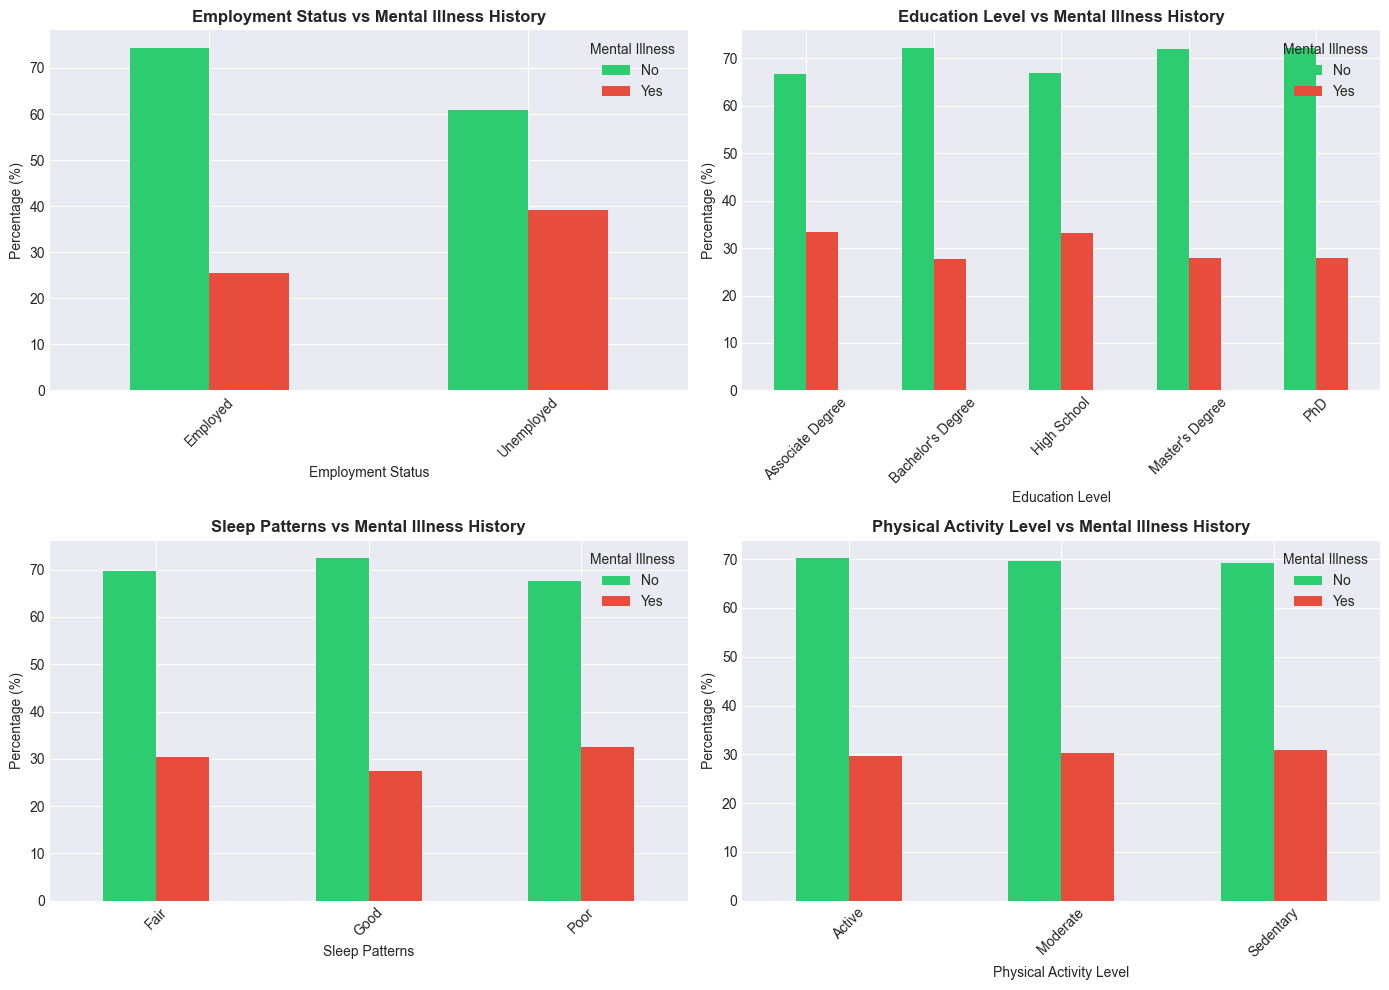

In [ ]:
# Categorical vs Target - Key Relationships
key_categorical = ['Employment Status', 'Education Level', 'Sleep Patterns', 'Physical Activity Level']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(key_categorical):
    ct = pd.crosstab(df[col], df['History of Mental Illness'], normalize='index') * 100
    ct.plot(kind='bar', stacked=False, ax=axes[i], color=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} vs Mental Illness History', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='Mental Illness', loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Key Insights:**
- Employment Status: Unemployment strongly associated with mental illness
- Education Level : Lower education associated with higher risk
- Sleep Pattern : Poor sleep correlates with higher mental illness rates
- Physical Activity : Lower activity levels linked to mental illness

### 2.2.4 Multivariate Analysis

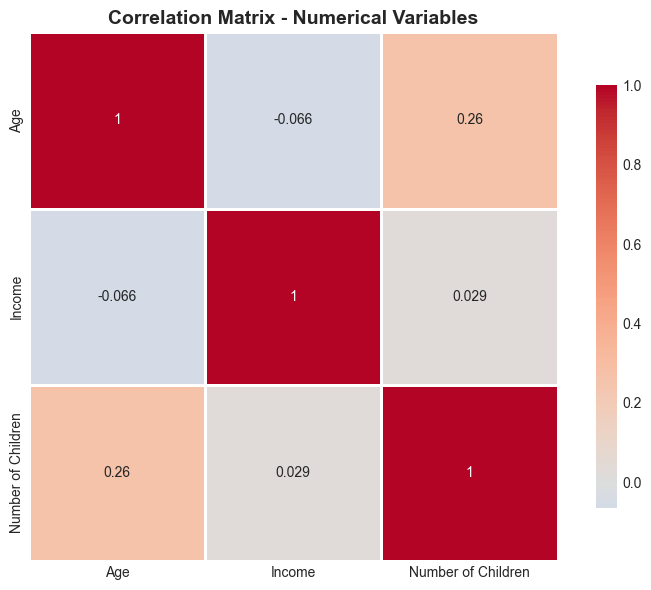

In [ ]:
# Correlation Analysis for Numerical Variables
plt.figure(figsize=(8, 6))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insights**:
- Numerical variables show weak correlations, suggesting independence.

---

# 3. Data Preparation

## 3.1 Data Cleaning

Based on EDA findings, minimal cleaning required due to high data quality.

In [ ]:
# Create working copy
df_clean = df.copy()

# Verify data quality
print("Data Quality Check:")
print(f"Missing Values: {df_clean.isnull().sum().sum()}")
print(f"Duplicate Rows: {df_clean.duplicated().sum()}")
print(f"\nData Shape: {df_clean.shape}")

# Outlier Assessment for Income
Q1 = df_clean['Income'].quantile(0.25)
Q3 = df_clean['Income'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_clean[(df_clean['Income'] < Q1 - 1.5*IQR) | (df_clean['Income'] > Q3 + 1.5*IQR)]
print(f"\nIncome Outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")
print("Decision: Retain outliers as they represent valid high-income individuals")

Data Quality Check:
Missing Values: 0
Duplicate Rows: 0

Data Shape: (413768, 16)

Income Outliers: 5157 (1.25%)
Decision: Retain outliers as they represent valid high-income individuals


## 3.2 Feature Engineering

Create additional features to enrich the model's learning capabilities.

In [ ]:
# Age Groups
df_clean['Age_Group'] = pd.cut(df_clean['Age'],
                               bins=[0, 25, 40, 55, 100],
                               labels=['Young Adult', 'Adult', 'Middle Age', 'Senior'])

# Income Categories
df_clean['Income_Category'] = pd.cut(df_clean['Income'],
                                     bins=[0, 30000, 60000, 100000, float('inf')],
                                     labels=['Low', 'Medium', 'High', 'Very High'])

# Risk Factor Count (composite feature)
risk_factors = ['Smoking Status', 'Alcohol Consumption', 'History of Substance Abuse']
df_clean['Risk_Factor_Count'] = (df_clean[risk_factors] != 'No').sum(axis=1)

print("Feature Engineering Complete:")
print(f"New features created: Age_Group, Income_Category, Risk_Factor_Count")
print(f"\nUpdated dataset shape: {df_clean.shape}")

Feature Engineering Complete:
New features created: Age_Group, Income_Category, Risk_Factor_Count

Updated dataset shape: (413768, 19)


**Key Insights**:
- Created 3 new features, Age_Group, Income_Category and Risk_Factor_Count
- Age_Group: Smoothing of age by binning them at certain age range
- Income_Category: Smoothing of income by binning them at certain income range
- Risk_Factor_Count: Calculate the count of risks present for each sample

## 3.3 Data Transformation

### 3.3.1 Encoding Categorical Variables

In [ ]:
# Separate features and target
X = df_clean.drop(['History of Mental Illness'], axis=1)
y = df_clean['History of Mental Illness']

# Encode target variable
y_encoded = (y == 'Yes').astype(int)

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical Features ({len(categorical_features)}): {categorical_features[:5]}...")
print(f"Numerical Features ({len(numerical_features)}): {numerical_features}")

# Label Encoding for categorical variables
X_encoded = X.copy()
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le

Categorical Features (14): ['Name', 'Marital Status', 'Education Level', 'Smoking Status', 'Physical Activity Level']...
Numerical Features (4): ['Age', 'Number of Children', 'Income', 'Risk_Factor_Count']


**Key Insights**:
- Implemented label encoder (nominal encoding) for categorical features to convert them into numerical values

### 3.3.2 Feature Scaling

In [ ]:
# Standardize numerical features
scaler = StandardScaler()
X_encoded[numerical_features] = scaler.fit_transform(X_encoded[numerical_features])

In [ ]:
original_values = df_clean[numerical_features].describe().T[['mean','std']] \
    .rename(columns={
        'mean': 'mean-original',
        'std': 'std-original'
    })

scaled_values = X_encoded[numerical_features].describe().T[['mean','std']] \
    .rename(columns={
        'mean': 'mean-scaled',
        'std': 'std-scaled'
    })

comparison_scaling = pd.concat([original_values, scaled_values], axis=1)
comparison_scaling.round(2)

,mean-original,std-original,mean-scaled,std-scaled
Age,49.00,18.16,0.0,1.0
Number of Children,1.30,1.24,-0.0,1.0
Income,50661.71,40624.10,0.0,1.0
Risk_Factor_Count,2.31,0.46,0.0,1.0


**Key Insights**:
- Succesfully scaled using a standard z-score method, as evident with the mean and standard deviation of the numerical variables all at 0 and 1 respectively.

## 3.4 Train-Test Split

In [ ]:
# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train-Test Split Complete:")
print(f"Training Set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"Test Set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"\nClass Distribution in Training Set:")
print(y_train.value_counts(normalize=True))
print(f"\nClass Distribution in Test Set:")
print(y_test.value_counts(normalize=True))

Train-Test Split Complete:
Training Set: 331014 samples (80.0%)
Test Set: 82754 samples (20.0%)

Class Distribution in Training Set:
History of Mental Illness
0    0.695904
1    0.304096
Name: proportion, dtype: float64

Class Distribution in Test Set:
History of Mental Illness
0    0.695906
1    0.304094
Name: proportion, dtype: float64


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 331014 entries, 352067 to 110548
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Name                          331014 non-null  int64  
 1   Age                           331014 non-null  float64
 2   Marital Status                331014 non-null  int64  
 3   Education Level               331014 non-null  int64  
 4   Number of Children            331014 non-null  float64
 5   Smoking Status                331014 non-null  int64  
 6   Physical Activity Level       331014 non-null  int64  
 7   Employment Status             331014 non-null  int64  
 8   Income                        331014 non-null  float64
 9   Alcohol Consumption           331014 non-null  int64  
 10  Dietary Habits                331014 non-null  int64  
 11  Sleep Patterns                331014 non-null  int64  
 12  History of Substance Abuse    331014 non-nul

**Key Insights**:
- Deploy a 80-20 train test split
- The 18 features used are as above with all being in numerical format.

---

# 4. Modeling

## 4.1 Modeling Strategy

We evaluate 5 classification algorithms:

1. **Logistic Regression**
2. **Random Forest**
3. **XGBoost**
4. **LightGBM**
5. **CatBoost**

**Training Phases:**
- Phase 1: Default configurations (baseline)
- Phase 2: Class balancing to address imbalance
- Phase 3: Hyperparameter tuning of best model

## 4.2 Model Training - Phase 1 (Baseline)

In [ ]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

# Train and evaluate models
results_phase1 = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results_phase1[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
    }
    print(f"{name} - AUC-ROC: {results_phase1[name]['AUC-ROC']:.4f}\n")

# Display results
results_df_phase1 = pd.DataFrame(results_phase1).T
print("\nPhase 1 Results (Baseline):")
print(results_df_phase1.round(4))

Training Logistic Regression...
Logistic Regression - AUC-ROC: 0.5920

Training Random Forest...
Random Forest - AUC-ROC: 0.5659

Training XGBoost...
XGBoost - AUC-ROC: 0.5916

Training LightGBM...
LightGBM - AUC-ROC: 0.5968

Training CatBoost...
CatBoost - AUC-ROC: 0.5938


Phase 1 Results (Baseline):
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.6959     0.0000  0.0000    0.0000   0.5920
Random Forest          0.6804     0.3657  0.0695    0.1168   0.5659
XGBoost                0.6944     0.4100  0.0111    0.0217   0.5916
LightGBM               0.6958     0.3333  0.0003    0.0006   0.5968
CatBoost               0.6950     0.3931  0.0054    0.0107   0.5938


## 4.3 Model Training - Phase 2 (Class Balancing)

In [ ]:
# Initialize models with class balancing
models_balanced = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=2.33),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0, auto_class_weights='Balanced')
}

# Train and evaluate
results_phase2 = {}

for name, model in models_balanced.items():
    print(f"Training {name} with class balancing...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results_phase2[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
    }
    print(f"{name} - Recall: {results_phase2[name]['Recall']:.4f}, AUC-ROC: {results_phase2[name]['AUC-ROC']:.4f}\n")

# Display results
results_df_phase2 = pd.DataFrame(results_phase2).T
print("\nPhase 2 Results (With Class Balancing):")
print(results_df_phase2.round(4))

Training Logistic Regression with class balancing...
Logistic Regression - Recall: 0.4788, AUC-ROC: 0.5920

Training Random Forest with class balancing...
Random Forest - Recall: 0.0567, AUC-ROC: 0.5671

Training XGBoost with class balancing...
XGBoost - Recall: 0.5923, AUC-ROC: 0.5921

Training LightGBM with class balancing...
LightGBM - Recall: 0.5383, AUC-ROC: 0.5968

Training CatBoost with class balancing...
CatBoost - Recall: 0.5745, AUC-ROC: 0.5941


Phase 2 Results (With Class Balancing):
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.6055     0.3816  0.4788    0.4247   0.5920
Random Forest          0.6826     0.3610  0.0567    0.0981   0.5671
XGBoost                0.5580     0.3616  0.5923    0.4490   0.5921
LightGBM               0.5842     0.3728  0.5383    0.4405   0.5968
CatBoost               0.5663     0.3647  0.5745    0.4462   0.5941


**Key Findings**:
- To address class imbalance, we implemented "Class Weight" approach, which the model applies higher weightage on minority class


# 4.4 Hyperparameter Tuning (Best Model)

In [ ]:
# Select best performing model from Phase 2
best_model_name = results_df_phase2['AUC-ROC'].idxmax()
print(f"Best Model from Phase 2: {best_model_name}")
print(f"AUC-ROC: {results_df_phase2.loc[best_model_name, 'AUC-ROC']:.4f}")

# Hyperparameter tuning for Best Model
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50]
}

lgbm = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')

print("\nPerforming Grid Search (this may take time)...")
grid_search = GridSearchCV(lgbm, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV AUC-ROC: {grid_search.best_score_:.4f}")

# Evaluate tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_pred_proba_tuned = best_model.predict_proba(X_test)[:, 1]

print("\nTuned Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")

Best Model from Phase 2: LightGBM
AUC-ROC: 0.5968

Performing Grid Search (this may take time)...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
Best CV AUC-ROC: 0.6004

Tuned Model Performance:
Accuracy: 0.5880
Precision: 0.3741
Recall: 0.5274
F1-Score: 0.4377
AUC-ROC: 0.5969


In [ ]:
best_model_optimised = grid_search.best_estimator_
train_auc = roc_auc_score(y_train, best_model_optimised.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, best_model_optimised.predict_proba(X_test)[:, 1])

print(f"Training AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

Training AUC: 0.6069
Test AUC: 0.5969


**Key Findings**:
- The best model after considering imbalance data is LightGBM, hence we carry out a hyperparameter sweep to find the most optimal parameters
- The difference between your Training AUC ($0.6069$) and Test AUC ($0.5969$) is only $0.01$. This means that the model is generalized.

---

# 5. Evaluation

## 5.1 Model Comparison

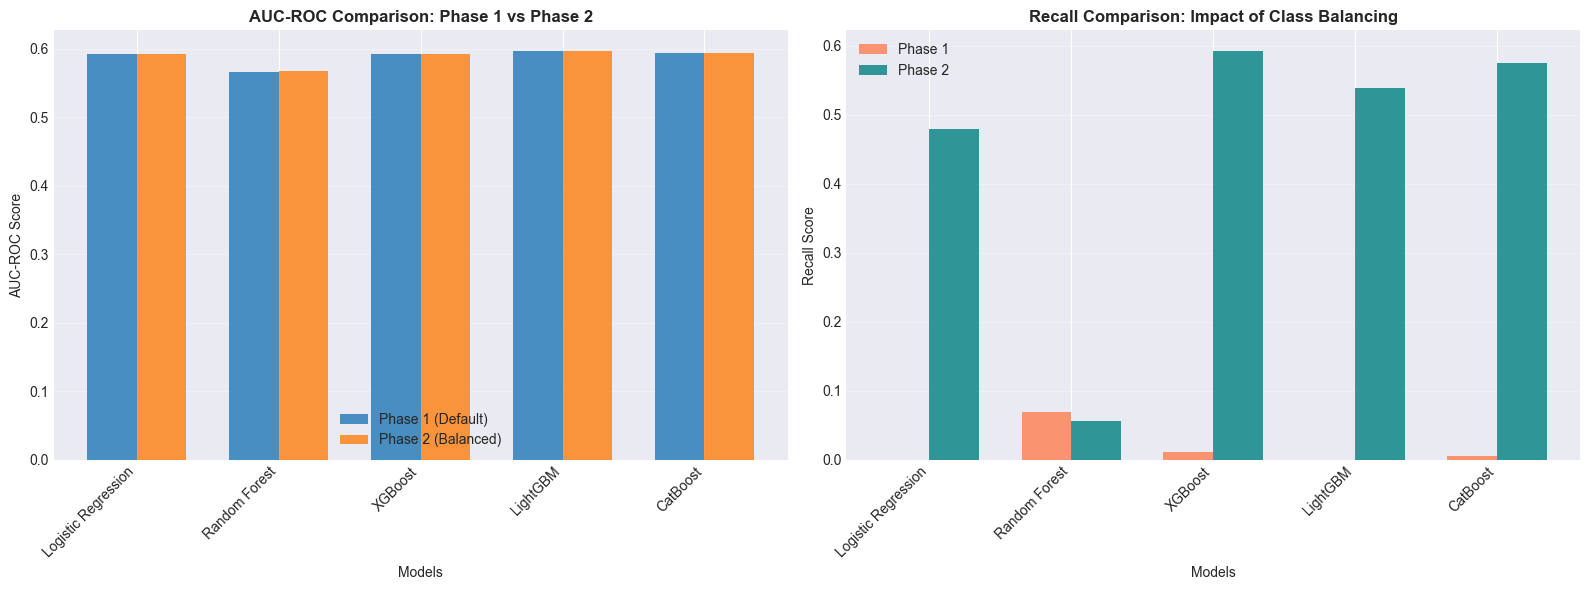

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Phase 1 vs Phase 2 Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(models))
width = 0.35

# AUC-ROC Comparison
auc_phase1 = [results_phase1[model]['AUC-ROC'] for model in models.keys()]
auc_phase2 = [results_phase2[model]['AUC-ROC'] for model in models.keys()]

axes[0].bar(x - width/2, auc_phase1, width, label='Phase 1 (Default)', alpha=0.8)
axes[0].bar(x + width/2, auc_phase2, width, label='Phase 2 (Balanced)', alpha=0.8)
axes[0].set_xlabel('Models')
axes[0].set_ylabel('AUC-ROC Score')
axes[0].set_title('AUC-ROC Comparison: Phase 1 vs Phase 2', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models.keys(), rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Recall Comparison (Critical for healthcare)
recall_phase1 = [results_phase1[model]['Recall'] for model in models.keys()]
recall_phase2 = [results_phase2[model]['Recall'] for model in models.keys()]

axes[1].bar(x - width/2, recall_phase1, width, label='Phase 1', alpha=0.8, color='coral')
axes[1].bar(x + width/2, recall_phase2, width, label='Phase 2', alpha=0.8, color='teal')
axes[1].set_xlabel('Models')
axes[1].set_ylabel('Recall Score')
axes[1].set_title('Recall Comparison: Impact of Class Balancing', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models.keys(), rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Key Insights**:
- On the right, a dramatic improvement in Recall is observed, from near-zero to around 0.5 for most model.s
- On the flip side, the AUC-ROC score drops minorly for most models after the Weight Balance approach.

## 5.2 Feature Importance Analysis

Computing SHAP values for feature importance...


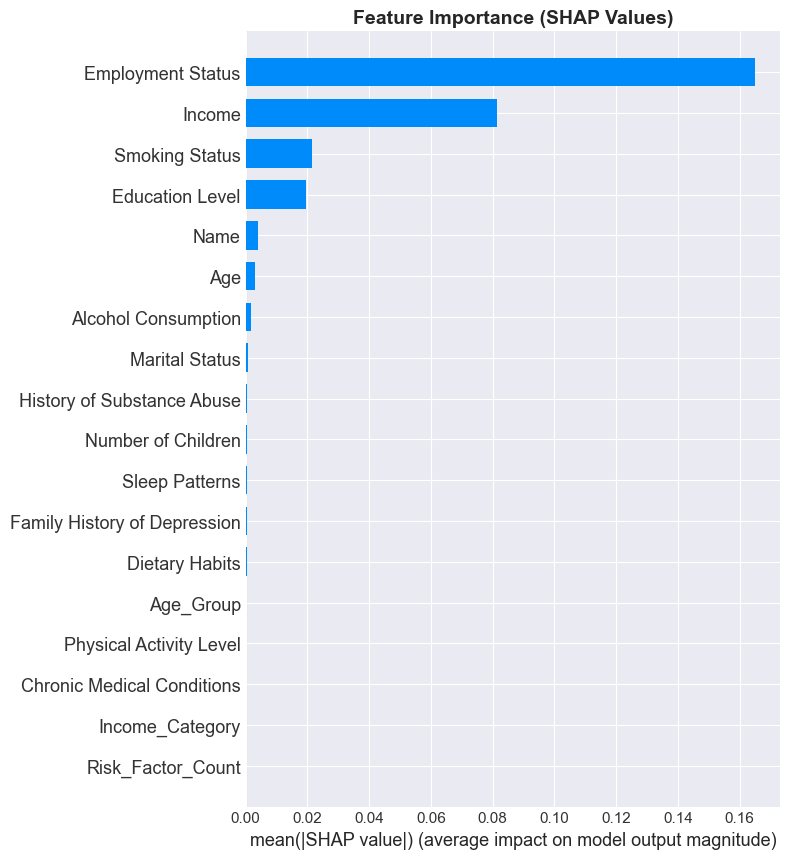

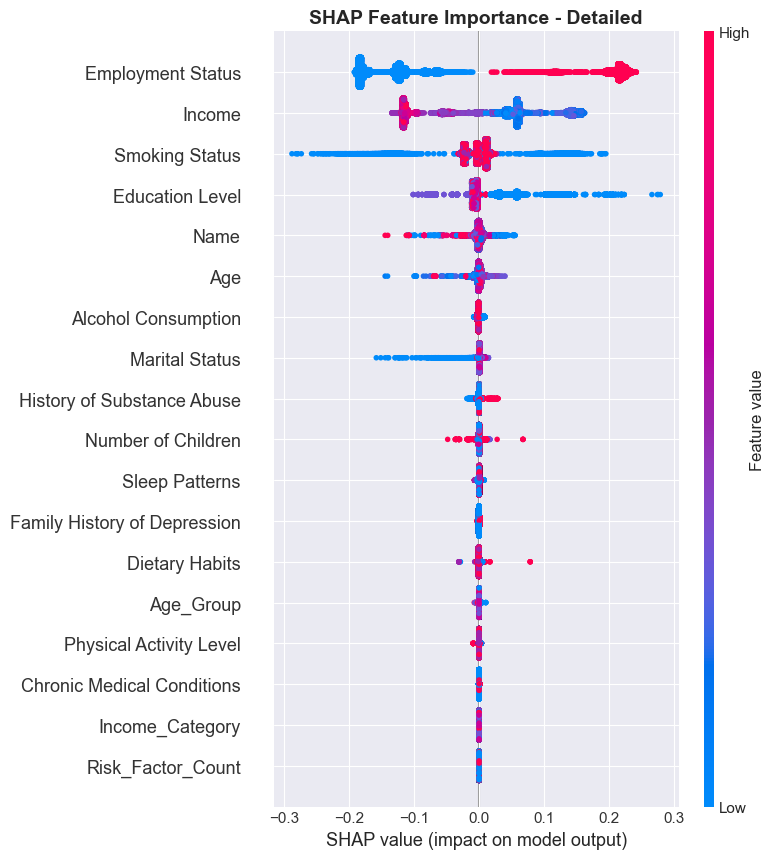

In [ ]:
# SHAP Analysis for model interpretability
print("Computing SHAP values for feature importance...")

# Use best model
explainer = shap.TreeExplainer(best_model_optimised)
shap_values = explainer.shap_values(X_test)

# For binary classification, we need to handle the output correctly
# shap_values might be a list [class_0_values, class_1_values] or a single array
if isinstance(shap_values, list):
    # Use positive class (class 1) SHAP values
    shap_values_to_plot = shap_values[1]
else:
    # Already the correct format
    shap_values_to_plot = shap_values

# Summary plot - Bar chart
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_to_plot, X_test, plot_type="bar", show=False)
plt.title('Feature Importance (SHAP Values)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed SHAP plot - Beeswarm/Dot plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_to_plot, X_test, show=False)
plt.title('SHAP Feature Importance - Detailed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insights**:
- 'Unemployment' emerges as the most influential predictor in our model based on the SHAP values, followed by 'Income' and 'Smoking Status'
- This could imply that income is one of the core factor, as someone who is unemployed technically would not have any income. Loss of income or low income is associated with financial stress, food insecurity, housing insecurity etc. causing someone to start experiencing mental health issues.

## 5.3 ROC Curve Analysis

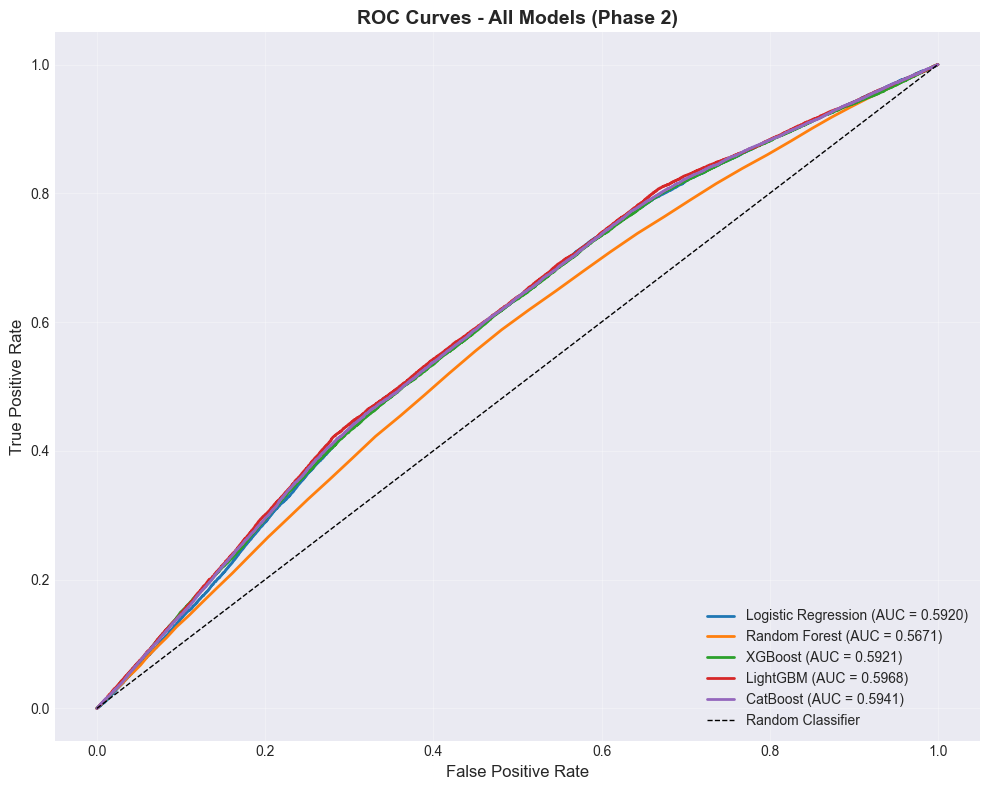

In [ ]:
# ROC Curves for all models (Phase 2)
plt.figure(figsize=(10, 8))

for name, model in models_balanced.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models (Phase 2)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Key Insights**:
- All models show similar discriminative ability (AUC ≈ 0.59), with gradient boosting methods (LightGBM, CatBoost, XGBoost) slightly outperforming traditional approaches.
- The curve allows for identification of optimal decision threshold that balances both True Positiive Rate and False Positive Rate.

## 5.4 Confusion Matrix (Best Model)

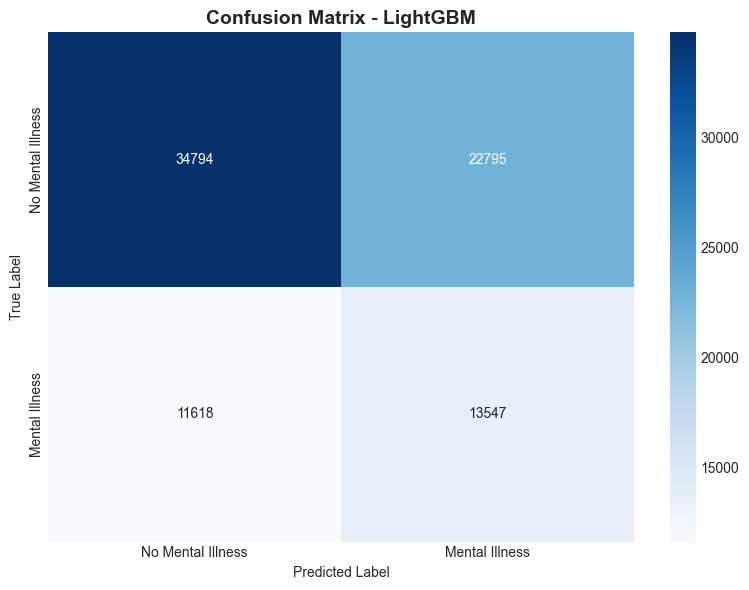


Confusion Matrix Breakdown:
True Negatives: 34794
False Positives: 22795
False Negatives: 11618
True Positives: 13547

Sensitivity (Recall): 0.5383
Specificity: 0.6042


In [ ]:
# Confusion matrix for best model
best_model_phase2 = models_balanced[best_model_name]
y_pred_best = best_model_phase2.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Mental Illness', 'Mental Illness'],
            yticklabels=['No Mental Illness', 'Mental Illness'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Calculate specific metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")
print(f"\nSensitivity (Recall): {tp/(tp+fn):.4f}")
print(f"Specificity: {tn/(tn+fp):.4f}")

**Key Insights**:
- The model correctly classified 48,341 cases (34,794 true negatives + 13,547 true positives) out of 86,754 total predictions, representing approximately 55.7% accuracy.
- The model generated 22,795 false negatives (individuals with mental illness predicted as healthy), which is a critical gap since it miss individuals that are actually ill.

---

# 6. Deployment

## 6.1 Deployment Considerations

**Deployment Strategy:**
- **Target Users:** Public health agencies, healthcare providers, social services
- **Use Case:** Risk screening tool for mental health outreach programs
- **Deployment Mode:** API service or integrated web application

**Monitoring Plan:**
- Track model performance monthly (AUC-ROC, recall)
- Monitor data drift in feature distributions
- Retrain quarterly with new data
- Maintain performance threshold: AUC-ROC > 0.55

## 6.2 Ethical Considerations

**Privacy:** Ensure data privacy compliance for health data

**Bias Mitigation:** Regular audits for demographic fairness

**Transparency:** Provide explainable predictions (SHAP values) to clinicians

**Human-in-the-Loop:** Model outputs support (not replace) clinical judgment

---

# 7. Conclusion

## 7.1 Summary of Findings

This project applied the CRISP-DM framework to develop predictive models for mental health risk assessment, addressing SDG 3 (Good Health and Well-being).

**Key Achievements:**
1. **Comprehensive EDA:** Identified income, employment, sleep, and physical activity as key risk factors
2. **Robust Preprocessing:** Cleaned, engineered, and transformed 413,768 records with 18 features
3. **Multi-Model Comparison:** Evaluated 5 ML algorithms with systematic hyperparameter tuning
4. **Interpretability:** SHAP analysis provided actionable insights for stakeholders

## 7.2 Limitations and Constraints

**Data Limitations:**
- Class imbalance (70-30) reduced minority class detection
- Limited clinical features (no therapy history, medication, genetic factors)

**Model Limitations:**
- AUC-ROC ~0.60 indicates marginal improvement over random guessing
- High false negative rate remains concern for healthcare application

## 7.3 Future Directions

**Data Enhancement:**
- Incorporate clinical assessments
- Collect genetic and family history details for better clinical features

**Methodological Improvements:**
- Alternative imbalance techniques (SMOTE, ADASYN)
- Deep learning approaches (neural networks)
- Ensemble stacking for improved performance

**Deployment Readiness:**
- Pilot study with healthcare providers
- External validation on diverse populations

---

# References

[1] World Health Organization. (2025). One billion people have mental health conditions, WHO says. BMJ, 390, r1860. https://doi.org/10.1136/bmj.r1860

[2] Latkin, C. A., et al. (2017). The relationship between social desirability bias and self-reports of health, substance use, and social network factors among urban substance users in Baltimore, Maryland. Addictive Behaviors, 73, 133-136. PMC5519338.

[3] Khan, S., et al. (2024). A machine learning based depression screening framework using temporal domain features of the electroencephalography signals. PLOS ONE, 19(3), e0299127.

**End of Report**